## Testing diffrent neural network architectures
In this expriement, i am going to train diffrent neural networks that have diffrent architectures; Then ranking each one based on:
Training time, Testing accuracy and Testing loss.
We use the MNIST hand-written digits dataset for this expriment

### We test two part aspects of neural network design:

#### 1-Depth: How many layers the model has

#### 2-Width: How many neurons each layer has.

In [1]:
#Change directory for importing 

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
#Load and preprocess MNIST dataset from keras
from load_mnist import load_handwritten_digits

X_train, y_train, X_test, y_test = load_handwritten_digits()

In [22]:
import time #For calculating training time

n_depth = 4
width_container = [256, 128, 64, 32, 16]

depth_tests = dict() # {depth: (acc, loss, time)}
width_tests = dict() # {width: (acc, loss, time)}

In [4]:
from deep_neural_network.core.main_structure import NeuralNetwork #Import the net

In [18]:
rs = 455 #Fixed random state
lr = 0.001

In [25]:
#Test diffrent depths
for depth in range(1, n_depth + 1):
    print(f"---------------- {depth} hidden layers ----------------")

    nn = NeuralNetwork(
        n_features=784,
        task="MultiClassifier",
        learning_rate=lr,
        random_state=rs
    )

    for _ in range(depth):
        nn.add_layer(
            n_neuron=128,
            activation="ReLU",
            kernel_init="He",
            normalize=True
        )

    nn.add_layer(
        n_neuron=10,
        activation="Softmax",
        kernel_init="Xavier",
        normalize=False
    )

    nn.set_optimizer("RMSProp")

    start = time.perf_counter()

    nn.fit(
        X=X_train,
        y=y_train,
        epoch=5,
        batch_size=32,
        monitor_every_n=5
    )

    elapsed = time.perf_counter() - start
    accuracy, loss = nn.evaluate(X_test, y_test)

    depth_tests[depth] = (accuracy, loss, elapsed)

    print(f"Hidden layers: {depth}")
    print(f"Time: {elapsed:.2f}s")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Loss: {loss:.4f}")

---------------- 1 hidden layers ----------------
epoch: 5, loss: 0.029023716897541737
Hidden layers: 1
Time: 50.17s
Accuracy: 0.9761
Loss: 0.0761
---------------- 2 hidden layers ----------------
epoch: 5, loss: 0.019469324650107943
Hidden layers: 2
Time: 58.02s
Accuracy: 0.9792
Loss: 0.0657
---------------- 3 hidden layers ----------------
epoch: 5, loss: 0.02473434681097605
Hidden layers: 3
Time: 78.32s
Accuracy: 0.9796
Loss: 0.0700
---------------- 4 hidden layers ----------------
epoch: 5, loss: 0.02616144164224421
Hidden layers: 4
Time: 103.77s
Accuracy: 0.9790
Loss: 0.0724


In [23]:
#Test diffrent width
for width in width_container:
    print(f"---------------- {width} neurons ----------------")

    #Initialize the model
    nn = NeuralNetwork(
        n_features=784,
        task="MultiClassifier",
        learning_rate=lr,
        random_state=rs
    )

    #One hidden layer with n neurons
    nn.add_layer(
        n_neuron=width,
        activation="ReLU",
        kernel_init="He",
        normalize=True
    )

    #The output layer
    nn.add_layer(
        n_neuron=10,
        activation="Softmax",
        kernel_init="Xavier",
        normalize=False
    )

    nn.set_optimizer("RMSProp")

    start = time.perf_counter()

    nn.fit(
        X=X_train,
        y=y_train,
        epoch=5,
        batch_size=32,
        monitor_every_n=5
    )

    #Calculate training time, accuracy and loss
    elapsed = time.perf_counter() - start
    accuracy, loss = nn.evaluate(X_test, y_test)

    width_tests[width] = (accuracy, loss, elapsed)

    print(f"n neruons : {width}")
    print(f"Time: {elapsed:.2f}s")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Loss: {loss:.4f}")

---------------- 256 neurons ----------------
epoch: 5, loss: 0.023015028179814906
n neruons : 256
Time: 132.64s
Accuracy: 0.9794
Loss: 0.0684
---------------- 128 neurons ----------------
epoch: 5, loss: 0.029023716897541737
n neruons : 128
Time: 51.91s
Accuracy: 0.9761
Loss: 0.0761
---------------- 64 neurons ----------------
epoch: 5, loss: 0.04604923646062965
n neruons : 64
Time: 32.27s
Accuracy: 0.9744
Loss: 0.0904
---------------- 32 neurons ----------------
epoch: 5, loss: 0.08956505947101905
n neruons : 32
Time: 21.81s
Accuracy: 0.9672
Loss: 0.1221
---------------- 16 neurons ----------------
epoch: 5, loss: 0.15745525063248075
n neruons : 16
Time: 12.80s
Accuracy: 0.9474
Loss: 0.1770


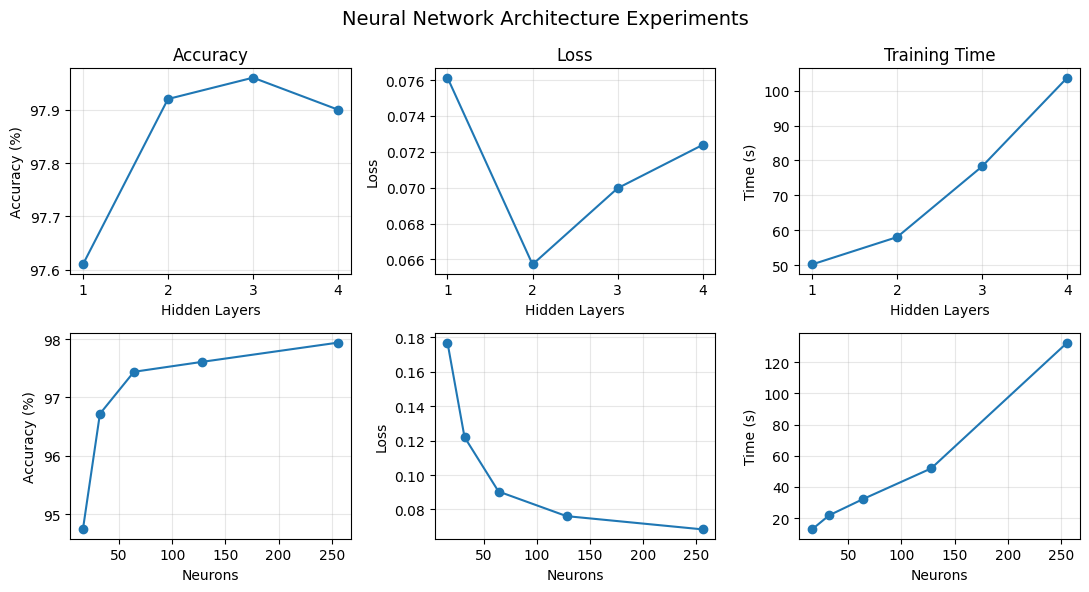

In [26]:
import matplotlib.pyplot as plt

# {depth/width: (accuracy, loss, time)}

# -------------------- Extract results --------------------

depth = list(depth_tests.keys())
depth_acc = [v[0] * 100 for v in depth_tests.values()]
depth_loss = [v[1] for v in depth_tests.values()]
depth_time = [v[2] for v in depth_tests.values()]

width = list(width_tests.keys())
width_acc = [v[0] * 100 for v in width_tests.values()]
width_loss = [v[1] for v in width_tests.values()]
width_time = [v[2] for v in width_tests.values()]


# -------------------- Plot --------------------

fig, axes = plt.subplots(2, 3, figsize=(11, 6))

# Accuracy
axes[0, 0].plot(depth, depth_acc, "o-")
axes[1, 0].plot(width, width_acc, "o-")

# Loss
axes[0, 1].plot(depth, depth_loss, "o-")
axes[1, 1].plot(width, width_loss, "o-")

# Time
axes[0, 2].plot(depth, depth_time, "o-")
axes[1, 2].plot(width, width_time, "o-")

# -------------------- Titles --------------------

axes[0, 0].set_title("Accuracy")
axes[0, 1].set_title("Loss")
axes[0, 2].set_title("Training Time")

# -------------------- Labels --------------------

axes[0, 0].set_ylabel("Depth")
axes[1, 0].set_ylabel("Width")

for ax in axes[0]:
    ax.set_xlabel("Hidden Layers")

for ax in axes[1]:
    ax.set_xlabel("Neurons")

axes[0, 0].set_ylabel("Accuracy (%)")
axes[1, 0].set_ylabel("Accuracy (%)")

# Correct row labels for the other plots
axes[0, 1].set_ylabel("Loss")
axes[1, 1].set_ylabel("Loss")

axes[0, 2].set_ylabel("Time (s)")
axes[1, 2].set_ylabel("Time (s)")

# -------------------- Grid --------------------

for ax in axes.flat:
    ax.grid(alpha=0.3)

fig.suptitle("Neural Network Architecture Experiments", fontsize=14)

plt.tight_layout()

plt.savefig("test_results\\architecture_test.png")
plt.show()